In [1]:
import TNGFunctions as TNG
import PlotFunctions as plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import MATH
import warnings
import os

from scipy.interpolate import interp1d
from astropy.cosmology import WMAP9 as cosmo
from astropy.cosmology import WMAP7
from matplotlib.lines import Line2D


plt.style.use('abhner.mplstyle')
np.seterr(divide='ignore') # ignore divide by zero


warnings.filterwarnings( "ignore")

In [2]:
# cosmological parameters
Omegam0 = 0.3089
h = 0.6774

#SIM TNG
SIMTNG = 'TNG50'

#Paths
dfTime = pd.read_csv(os.getenv("HOME")+'/TNG_Analyzes/SubhaloHistory/SNAPS_TIME.csv')
df_z0_Mstar_Range = TNG.extractDF('Sample', SIM=SIMTNG)
PaperIII = TNG.extractDF('PaperIII', SIM=SIMTNG)
PaperIV = PaperIII.copy()

In [3]:
# Selection
df_z0_Mstar_Size_Range = PaperIII.loc[PaperIII['logHalfRadstar_99'] > -0.25].copy()
df_z0_Mstar_Size_Range_Central = df_z0_Mstar_Size_Range.loc[df_z0_Mstar_Size_Range['CentralSatellite'] == 'Central'].copy()

In [25]:
def has_string(arr):
    return any(isinstance(x, str) for x in arr if not (isinstance(x, float) and np.isnan(x)))

In [4]:
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

def running_quantiles(x, y, frac=0.15, qs=(0.05, 0.25, 0.5, 0.75, 0.95), smooth=True, sg_window=21, sg_poly=2):
    """
    x: array de logM
    y: array de logRe
    frac: fração do sample na janela deslizante (0.1–0.2 funciona bem)
    qs: quantis a estimar
    smooth: suavizar com Savitzky–Golay (requer sg_window ímpar)
    retorna: dict {q: (x_grid, q_values_suaves)}
    """
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_sorted = y[idx]

    n = len(x_sorted)
    win = max(int(np.round(frac * n)), 30)  # janela mínima
    if win % 2 == 0: 
        win += 1

    # grid de avaliação (pontos-alvo ao longo de x)
    ngrid = min(400, n)
    x_grid = np.linspace(x_sorted[0], x_sorted[-1], ngrid)

    out = {}
    for q in qs:
        q_vals = np.empty(ngrid)
        half = win // 2
        for i, xv in enumerate(x_grid):
            # centro mais próximo
            k = np.searchsorted(x_sorted, xv)
            lo = max(0, k - half)
            hi = min(n, lo + win)
            lo = max(0, hi - win)  # garante tamanho da janela
            y_win = y_sorted[lo:hi]
            if len(y_win) < 5:  # fallback
                q_vals[i] = np.nan
            else:
                q_vals[i] = np.quantile(y_win, q)

        # suaviza e interpola
        if smooth:
            # trata NaNs antes de suavizar
            ok = np.isfinite(q_vals)
            q_vals_ok = np.interp(np.arange(ngrid), np.where(ok)[0], q_vals[ok]) if not ok.all() else q_vals
            # sg_window não pode exceder ngrid
            w = min(sg_window, (ngrid // 2) * 2 - 1)  # ímpar e < ngrid
            if w < 5: 
                w = 5
            if w % 2 == 0:
                w += 1
            q_vals_smooth = savgol_filter(q_vals_ok, window_length=w, polyorder=min(sg_poly, w-1))
        else:
            q_vals_smooth = q_vals

        out[q] = (x_grid, q_vals_smooth)

    return out

def build_quantile_interps(qcurves):
    """
    qcurves: dict {q: (x_grid, y_on_grid)} de running_quantiles
    retorna: dict {q: callable interp(x)}
    """
    interps = {}
    for q, (xg, yg) in qcurves.items():
        # bounds_error=False para extrapolar por 'nearest' nas bordas
        interps[q] = interp1d(xg, yg, kind='linear', bounds_error=False, fill_value='extrapolate')
    return interps

def classify_row(x, y, Q, delta=0.03):
    """
    x=logM, y=logRe
    Q: dict de interpoladores {0.05: f05, 0.25: f25, 0.75: f75, 0.95: f95}
    delta: margem (dex) para histerese
    """
    q05 = Q[0.05](x)
    q25 = Q[0.25](x)
    q75 = Q[0.75](x)
    q95 = Q[0.95](x)

    if y < (q05 - delta):
        return 'Compact'
    elif y < (q25 - delta):
        return 'SubCompact'
    elif y <= (q75 + delta):
        return 'Normal'
    elif y <= q95 + delta:
        return 'SubDiffuse'
    else:
        return 'Diffuse'

In [5]:
df = df_z0_Mstar_Size_Range_Central.copy()

x = df['logMstarRad_99'].values.astype(float)
y = df['logHalfRadstar_99'].values.astype(float)

# Remove não finitos
mfin = np.isfinite(x) & np.isfinite(y)
x = x[mfin]; y = y[mfin]
df = df.loc[mfin].copy()

# 1) quantis corridos
qcurves = running_quantiles(x, y, frac=0.2, qs=(0.05,0.25,0.5,0.75,0.95), smooth=True, sg_window=9, sg_poly=2)

# 2) interpoladores
Q = build_quantile_interps(qcurves)

# 3) classificar com margem delta
delta = 0.03  # ~0.03–0.05 dex costuma estabilizar bem
df['NamePaperIV'] = [classify_row(xx, yy, Q, delta=delta) for xx, yy in zip(x, y)]

# Se quiser recolocar no DF original (mantendo índices originais)
df_z0_Mstar_Size_Range_Central.loc[df.index, 'NamePaperIV'] = df['NamePaperIV']

In [6]:
def getValuesGivenName(df, Param, Name, ColumnName = 'NamePaperIV'):
    '''
    Function to get a Param from a df given a conditional Name
    Parameters
    ----------
    df : dataframe
    Param : param 
    Name : conditional name
    ColumnName : data frame column. 'Name'
    Returns
    -------
    Requested values
    -------
    Author: Abhner P. de Almeida (abhner.almeida AAT usp.br)
    '''

    values = df.loc[df[ColumnName] == Name, Param].values

    return values

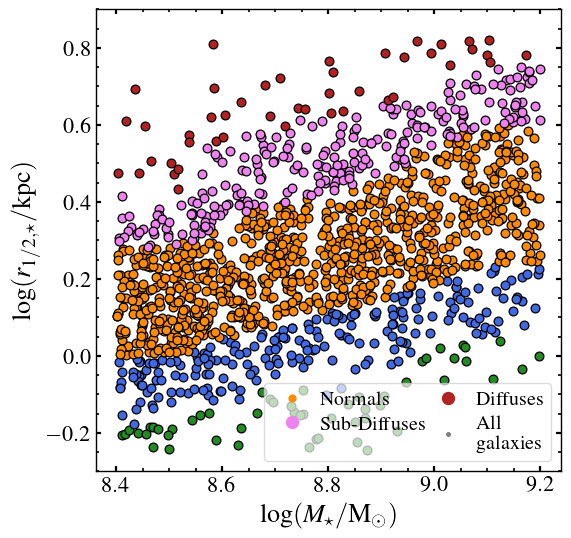

In [7]:
fig=plt.figure(facecolor='white')
plt.rcParams.update({'figure.figsize': (8, 8)})
X = np.transpose(np.array([df_z0_Mstar_Size_Range_Central.logMstarRad_99,df_z0_Mstar_Size_Range_Central.logHalfRadstar_99]))
Masses = np.linspace(8.4, 9.2, 100)


plt.scatter(X[:,0],X[:,1],s=5,c='gray',ec='none')

# Main branch

# Compact 

plt.scatter(getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logMstarRad_99', 'Compact'),
            getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logHalfRadstar_99', 'Compact'),
            s=40,c='forestgreen', linewidths= .9)

# SubCompact
plt.scatter(getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logMstarRad_99', 'SubCompact'),
            getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logHalfRadstar_99', 'SubCompact'),
            s=40,c='royalblue', linewidths= .9)


# Normals

plt.scatter(getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logMstarRad_99', 'Normal'),
            getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logHalfRadstar_99', 'Normal'),
            s=40,c='darkorange', linewidths= 0.9)


# SubDiffuse
plt.scatter(getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logMstarRad_99', 'SubDiffuse'),
            getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logHalfRadstar_99', 'SubDiffuse'),
            s=40,c='violet', linewidths= .9)


# Diffuse
plt.scatter(getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logMstarRad_99', 'Diffuse'),
            getValuesGivenName(df_z0_Mstar_Size_Range_Central, 'logHalfRadstar_99', 'Diffuse'),
            s=40,c='firebrick', linewidths= .9)



columnspacing = 0.2
handletextpad = 0.4
labelspacing = 0.3
fontlegend= 24
framealpha= 0.7
alphaScater=0.8
quantile=0.28

custom_lines, label, ncol, mult = plot.Legend(
    ['NormalScatter',  'SubDiffuseScatter', 'DiffuseScatter','TNGrageScatter'])
plt.legend(
    custom_lines, label, loc = 'lower right',  ncol=ncol, fontsize=mult*fontlegend, framealpha=framealpha, 
    columnspacing = columnspacing, handletextpad = handletextpad, labelspacing = labelspacing)

plt.ylim(-0.3, 0.9)
#plt.xlim(0, 10)
plt.tick_params(labelsize = 0.85 * 19)
plt.xlabel(r'$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 19)
plt.ylabel(r'$\log(r_{1/2, \star}/\mathrm{kpc})$', fontsize = 19)


plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/' + SIMTNG + '/PaperIV/PlotScatter/masssize.pdf')
plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/' + SIMTNG + '/PaperIV/PlotScatter/masssize.png')

In [8]:
for ID in df_z0_Mstar_Size_Range_Central.SubfindID_99.values:
    PaperIV.loc[PaperIV.SubfindID_99 == ID, 'NamePaperIV'] = df_z0_Mstar_Size_Range_Central.loc[df_z0_Mstar_Size_Range_Central.SubfindID_99 == ID, 'NamePaperIV'].values[0]

PaperIV.to_csv('/home/abhner/TNG_Analyzes/SubhaloHistory/TNG50/DFs/PaperIV.csv')

In [ ]:
PaperIV_new = PaperIV[[ 'Name', 'CentralSatellite', 'StatusBorn',
'ProgenitorStatus', 'GasStatus', 'SelectedStatus', 'Flags']].copy()
for k in PaperIV.keys().values:
    v = np.array([value for value in PaperIV[k].values])
    if not has_string(v):
        if len(v[np.isnan(v)]) > 30:
            continue
    else:
        if not k in PaperIV_new.keys().values:
            PaperIV_new[k] = PaperIV[k].values
for k in PaperIV.keys().values:
    v = np.array([value for value in PaperIV[k].values])
    if not has_string(v):
        if len(v[np.isnan(v)]) > 30:
            continue
        elif not k in PaperIV_new.keys().values:
            PaperIV_new[k] = PaperIV[k].values
    else:
        if not k in PaperIV_new.keys().values:
            PaperIV_new[k] = PaperIV[k].values

In [ ]:
PaperIVCentral = PaperIV_new.loc[PaperIV_new.CentralSatellite == 'Central'].copy()
PaperIVCentral.to_csv('/home/abhner/TNG_Analyzes/SubhaloHistory/TNG50/DFs/PaperIVCentral.csv')

In [9]:
df_z0_Mstar_Size_Range_Central.to_csv('/home/abhner/TNG_Analyzes/SubhaloHistory/TNG50/DFs/PaperIV_df_z0_Mstar_Size_Range_Central.csv')

In [16]:
PaperIV

,SubfindID_99,logMstarRad_99,logHalfRadstar_99,Flags,GMMIndex,Name,CentralSatellite,StatusBorn,ProgenitorStatus,GasStatus,...,DeltaRadIn_Ex,DeltaVRadIn_Ex,DeltaSigmaRadIn_Ex,RadIn,RadEx,VRadIn,VRadEx,SigmaIn,SigmaEx,NamePaperIV
0,45,9.092222,0.514900,1.0,0,Normal,Satellite,BornOld,WithProgenitor,DontLoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,48,9.149221,0.385765,1.0,0,Normal,Satellite,BornOld,WithProgenitor,DontLoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,53,9.037461,0.581932,1.0,0,SubDiffuse,Satellite,BornOld,WithProgenitor,DontLoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,57,8.825593,0.307577,1.0,0,Normal,Satellite,BornOld,WithProgenitor,DontLoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62,9.088788,0.137477,1.0,0,NaN,Satellite,BornOld,WithProgenitor,DontLoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3281,934186,8.480942,0.280069,1.0,0,SubDiffuse,Satellite,BornOld,WithProgenitor,LoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3282,935360,8.503038,0.227046,1.0,0,Normal,Satellite,BornOld,WithProgenitor,LoseTheirGas,...,-4.382289,-0.672814,0.582301,1.516986,5.899275,-0.231245,0.441569,41.316953,40.734653,NaN
3283,947737,8.864115,-0.530989,0.0,1,SBC,Satellite,BornYoung,WithProgenitor,DontLoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3284,994315,8.417047,0.015062,1.0,0,NaN,Satellite,BornOld,WithProgenitor,LoseTheirGas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
SubhaloSpin = TNG.extractDF('SubhaloSpin')

In [23]:
SubhaloSpin[[str(i) for i in PaperIV.SubfindID_99.values]]

,45,48,53,57,62,69,75,83,84,85,...,906316,913099,919596,920328,923816,934186,935360,947737,994315,1018223
0,2.209456,1.892781,2.434402,2.513483,2.047859,2.371312,1.713245,2.588800,1.818631,2.097064,...,0.908004,0.881705,0.868607,0.869706,0.385536,0.712535,1.162175,0.813021,0.010665,NaN
1,2.231019,2.019893,2.517461,2.491648,1.970022,2.368986,1.636235,2.568164,1.785445,2.126680,...,0.824292,0.927700,0.860598,0.911949,0.420038,0.903127,1.160373,0.805490,0.014812,NaN
2,2.239969,2.176364,2.418490,2.494228,1.857856,2.365737,1.735921,2.619835,1.741285,2.217529,...,0.903406,0.703871,0.877114,0.940553,0.497706,1.011737,1.179495,0.811527,-0.009483,NaN
3,2.279489,2.191266,2.371680,2.489701,1.808576,2.348922,1.644036,2.572150,1.689617,2.156021,...,1.054959,0.733464,0.884792,0.898511,0.479044,0.929987,1.169319,NaN,-0.421239,NaN
4,2.293815,2.229359,2.496776,2.527060,1.961288,2.389304,1.814324,2.563064,1.777300,2.212167,...,1.072585,0.728416,0.887619,0.737007,0.469907,0.748441,1.188376,NaN,0.025350,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.067094,1.051594,0.825989,0.378973,0.012711,0.580879,0.489109,-0.026000,-0.062758,0.570563,...,0.304393,0.005892,1.445234,-0.021612,NaN,1.143279,0.696073,NaN,0.886095,NaN
96,-0.018964,0.695593,1.030673,0.252837,-0.029334,0.500917,0.268447,-0.204090,-0.065857,0.562001,...,0.189985,0.280123,1.277918,-0.020013,NaN,0.575946,-0.638189,NaN,0.466426,NaN
97,-0.235060,0.217342,-0.016233,-0.084191,-0.296739,0.269221,0.053521,NaN,0.090197,0.603909,...,-0.054964,0.282154,1.039445,0.134303,NaN,0.553047,0.722673,NaN,0.700069,NaN
98,NaN,-0.507386,-0.192534,-1.077974,-0.257433,0.262702,-0.150111,NaN,NaN,0.170170,...,-0.410230,-0.103768,0.381588,NaN,NaN,-0.167877,0.304646,NaN,-0.069587,NaN


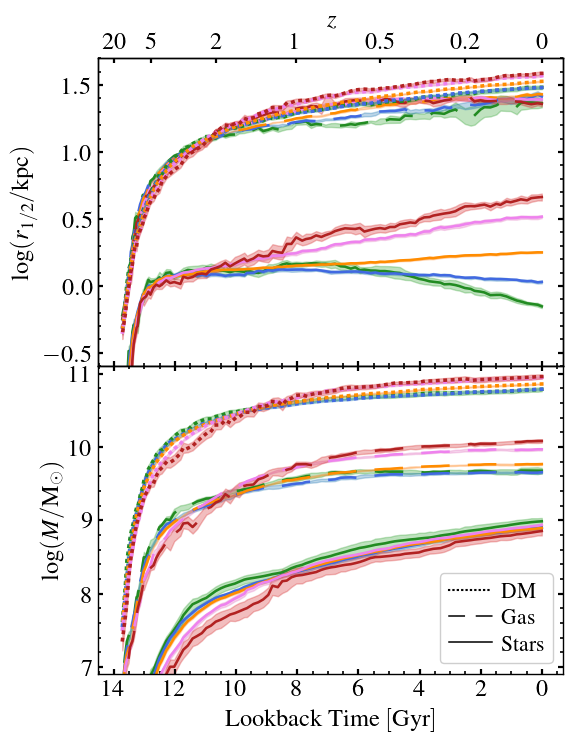

In [10]:
plot.PlotMedianEvolution(['Compact', 'SubCompact', 'Normal', 'SubDiffuse', 'Diffuse'], ['Central'],  
                         [['SubhaloHalfmassRadType0', 'SubhaloHalfmassRadType1', 'SubhaloHalfmassRadType4'], ['SubhaloMassType0', 'SubhaloMassType1', 'SubhaloMassType4']], 
                     Type='Evolution', Xparam=['Time'], 
                        xlabelintext=True, lineparams=True,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False,
                        savepath='PaperIV/PlotMedianEvolution',  savefigname='MassesSize', dfName='PaperIV', SampleName='SubfindID_99', Name=  'NamePaperIV',
                        Supertitle_Name = 'DM-rich',LegendNames=[['Type1', 'Type0',  'Type4']],
                        loctext = ['best'],
                        ylimmin = [-0.6, 6.9], ylimmax = [1.7, 11.1], xlimmin = None, xlimmax = None,
                        legpositions = [[0, 1]],
                        loc = ['best'],
                        lNum = 4, cNum = 6,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95, fontlabel=17.75,    nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)


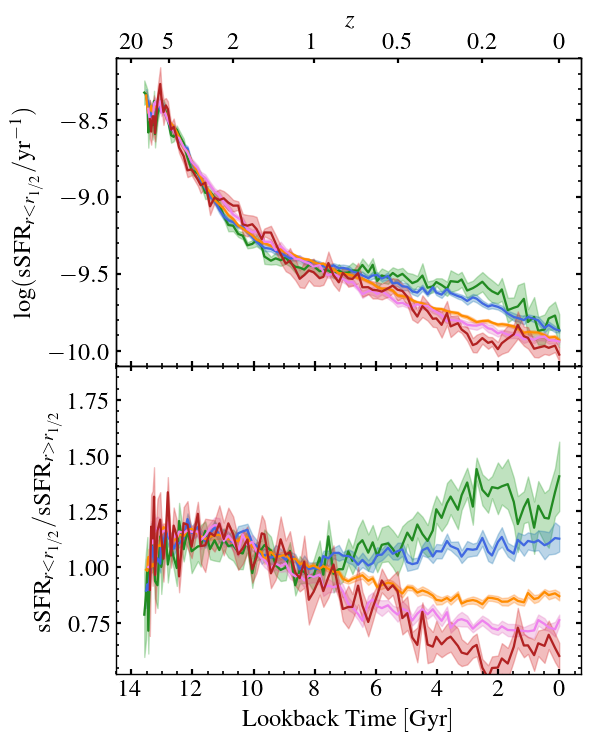

In [11]:
plot.PlotMedianEvolution(['Compact', 'SubCompact', 'Normal', 'SubDiffuse', 'Diffuse'], ['Central'],  [ 'SubhalosSFRInHalfRad', 'sSFRCoreRatio'], 
                     Type='Evolution', Xparam=['Time'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True,  GridMake = False,
                        ColumnPlot=True, limaxis=True,  legend=False,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False,
                        savepath='PaperIV/PlotMedianEvolution',  savefigname='SFR', dfName='PaperIV', SampleName='SubfindID_99',   Name=  'NamePaperIV',
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC']],
                        legpositions = [[0,0]],
                        loc = ['best'], 
                        loctext = ['best'],
                        ylimmin = [-10.1, 0.52], ylimmax = [-8.1, 1.9], xlimmin = None, xlimmax = None,
                        lNum = 4, cNum = 6,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95, fontlabel=17.75,  nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

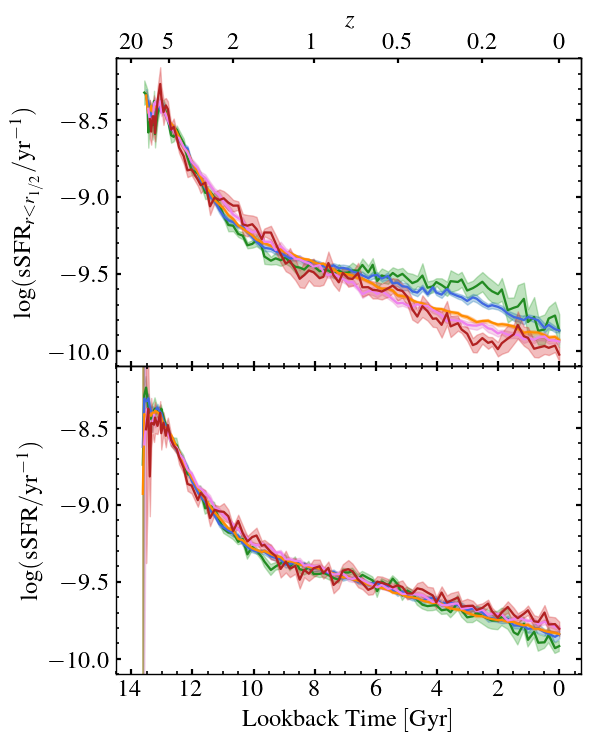

In [21]:
plot.PlotMedianEvolution(['Compact', 'SubCompact', 'Normal', 'SubDiffuse', 'Diffuse'], ['Central'],  [ 'SubhalosSFRInHalfRad', 'SubhalosSFR'], 
                     Type='Evolution', Xparam=['Time'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True,  GridMake = False,
                        ColumnPlot=True, limaxis=True,  legend=False,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False,
                        savepath='PaperIV/PlotMedianEvolution',  savefigname='sSFR', dfName='PaperIV', SampleName='SubfindID_99',   Name=  'NamePaperIV',
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC']],
                        legpositions = [[0,0]],
                        loc = ['best'], 
                        loctext = ['best'],
                        ylimmin = [-10.1, -10.1], ylimmax = [-8.1, -8.1], xlimmin = None, xlimmax = None,
                        lNum = 4, cNum = 6,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95, fontlabel=17.75,  nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

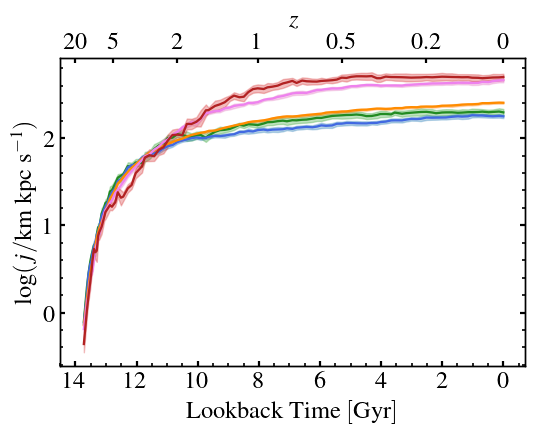

In [26]:
plot.PlotMedianEvolution(['Compact', 'SubCompact', 'Normal', 'SubDiffuse', 'Diffuse'], ['Central'],  [ 'SubhaloSpin'], 
                     Type='Evolution', Xparam=['Time'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True,  GridMake = False,
                        ColumnPlot=True, limaxis=True,  legend=False,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False,
                        savepath='PaperIV/PlotMedianEvolution',  savefigname='Spin', dfName='PaperIV', SampleName='SubfindID_99',   Name=  'NamePaperIV',
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC']],
                        legpositions = [[0,0]],
                        loc = ['best'], 
                        loctext = ['best'],
                        #ylimmin = [-10.1, -10.1], ylimmax = [-8.1, -8.1], xlimmin = None, xlimmax = None,
                        lNum = 4, cNum = 6,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95, fontlabel=17.75,  nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)


 Type:  Central
Compact  X =  0.01352233507571625 Y =  0.06544688112331659
SubCompact  X =  0.011484591932269 Y =  0.0645607424389457
Normal  X =  0.0101413323347098 Y =  0.0746132704713226
SubDiffuse  X =  0.00878122232461845 Y =  0.09695661165614389
Diffuse  X =  0.0066406257278907 Y =  0.1189856104393588

 Type:  Central
Compact  X =  0.01352233507571625 Y =  0.9213390813876202
SubCompact  X =  0.011484591932269 Y =  0.9228905227237196
Normal  X =  0.0101413323347098 Y =  0.914159386199061
SubDiffuse  X =  0.00878122232461845 Y =  0.8939643232964578
Diffuse  X =  0.0066406257278907 Y =  0.873852940013703


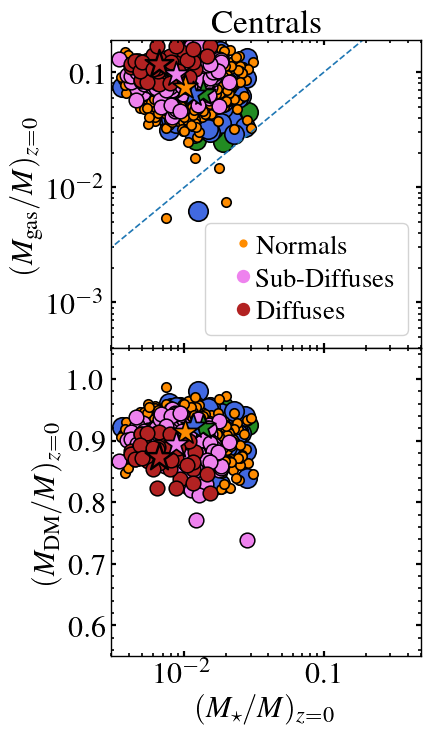

In [12]:
plot.PlotScatter(['Compact', 'SubCompact', 'Normal', 'SubDiffuse', 'Diffuse'], ['Central'], 'StarFrac_99', ['GasFrac_99', 'DMFrac_99'],  Type='z0', snap=[99],
                medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalScatter', 'SubDiffuseScatter', 'DiffuseScatter']],  TRANSPARENT = False, COLORBAR = None, medianDot = True, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2,  fontlabel=22, 
                m='o', msizet=14, quantile=0.95,framealpha = 0.85, q = 0.95,
                ylimmin = [0.0004, 0.55], ylimmax = [0.19, 1.05], xlimmin = [0.003, 0.003], xlimmax = [0.1, 0.5], MarkerSizes = None,
                legpositions = [[0,0]],
                loc = ['best'],
                lNum = 4, cNum = 4, msizeMult = 1.5,
                columnspacing = 0.5, handletextpad = -0.5, labelspacing = 0.3,  title= ['Centrals', 'Satellites'],
                savepath='PaperIV/PlotScatter',  savefigname='GasStarFracs',  dfName='PaperIV', SampleName='SubfindID_99',   Name=  'NamePaperIV',  cmap = 'inferno',
                bins=10, seed=16010504, mult = 4.1)